In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, ticker

In [2]:
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

In [3]:
path = './sweep6-31g/'

In [4]:
alldata = np.zeros((40, 40))

In [5]:
start = 1e-4
end = 2e-3
ratio = np.exp(np.log(end/start)/39)
print(ratio)
intensity = start * (ratio**np.arange(40))
print(intensity)

start = 1e-3
end = 5e-2
ratio = np.exp(np.log(end/start)/39)
print(ratio)
freq = start * (ratio**np.arange(40))
print(freq)

1.07984082718679
[0.0001     0.00010798 0.00011661 0.00012592 0.00013597 0.00014682
 0.00015855 0.00017121 0.00018487 0.00019964 0.00021557 0.00023279
 0.00025137 0.00027144 0.00029311 0.00031652 0.00034179 0.00036908
 0.00039854 0.00043036 0.00046472 0.00050183 0.00054189 0.00058516
 0.00063188 0.00068233 0.00073681 0.00079563 0.00085916 0.00092775
 0.00100183 0.00108181 0.00116819 0.00126145 0.00136217 0.00147093
 0.00158837 0.00171518 0.00185212 0.002     ]
1.105511675109074
[0.001      0.00110551 0.00122216 0.00135111 0.00149367 0.00165126
 0.00182549 0.0020181  0.00223104 0.00246644 0.00272667 0.00301437
 0.00333242 0.00368403 0.00407274 0.00450246 0.00497752 0.00550271
 0.00608331 0.00672517 0.00743476 0.00821921 0.00908643 0.01004516
 0.01110504 0.01227675 0.01357209 0.0150041  0.01658721 0.01833735
 0.02027216 0.02241111 0.02477574 0.02738987 0.03027982 0.0334747
 0.03700667 0.04091131 0.04522793 0.05      ]


In [6]:
delay = 50
for i in range(40):
    for j in range(40):
        freqstr = f"{freq[i]:.6f}"
        istr = f"{intensity[j]:.6f}"
        target_file='fci_h2_6-31g_0.050000_'+str(delay)+'_'+freqstr+'_'+istr+'_1.txt'
        f = np.loadtxt(path + target_file, skiprows=2, delimiter=',')
        alldata[i, j] = f[1]

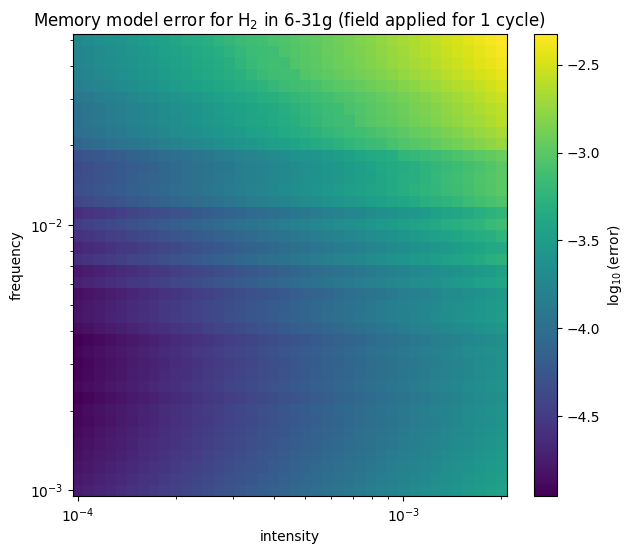

In [12]:

# freq, intensity, alldata as before
Z = np.log10(alldata)

# Build 2D grid edges for pcolormesh.
# For 1D arrays x of length N, create edges of length N+1 by geometric mean for log-spaced data:
def edges_from_centers(centers):
    # geometric edges for log-spaced centers
    edges = np.empty(len(centers) + 1)
    edges[1:-1] = np.sqrt(centers[:-1] * centers[1:])
    edges[0] = centers[0]**2 / edges[1]
    edges[-1] = centers[-1]**2 / edges[-2]
    return edges

x_edges = edges_from_centers(intensity)   # columns -> x
y_edges = edges_from_centers(freq)        # rows -> y

plt.figure(figsize=(7,6))
# Note: pcolormesh expects Z shape (Ny, Nx) where Ny = len(y_centers), Nx = len(x_centers)
mesh = plt.pcolormesh(x_edges, y_edges, Z, shading='auto', cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.title(r'Memory model error for H$_2$ in 6-31g (field applied for 1 cycle)')
cbar = plt.colorbar(mesh)
cbar.set_label(r'$\log_{10}$(error)')

plt.gca().xaxis.set_major_locator(LogLocator(base=10))
plt.gca().yaxis.set_major_locator(LogLocator(base=10))
plt.gca().xaxis.set_major_formatter(LogFormatterSciNotation())
plt.gca().yaxis.set_major_formatter(LogFormatterSciNotation())

plt.savefig('sweepdelay50_6-31g.pdf', bbox_inches='tight')
plt.show()
plt.close('all')


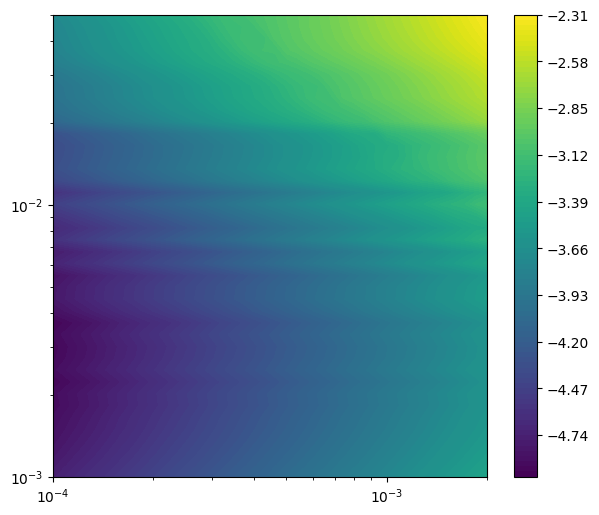

In [27]:
# freq, intensity, 
plt.figure(figsize=(7,6))
plt.contourf(intensity, freq, Z, levels=100)
plt.xscale('log')
plt.yscale('log')
plt.colorbar()
plt.show()

In [51]:
alldata[9,9,1]

np.float64(5.358817970150867e-07)

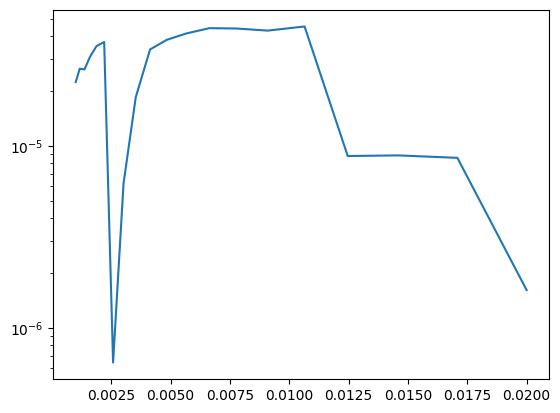

In [34]:
plt.semilogy(freq, alldata[:,9])
plt.show()

In [43]:
1 / 1e-3

1000.0